In [23]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
segments = pd.read_csv(
    "data/processed/customer_segments.csv"
)

churn = pd.read_csv(
    "data/processed/churn_predictions.csv"
)

clv = pd.read_csv(
    "data/processed/clv_predictions.csv"
)

features = pd.read_csv(
    "data/processed/customer_features.csv"
    
)

print("Segments")
print(segments.columns.tolist())

print("\nChurn")
print(churn.columns.tolist())

print("\nCLV")
print(clv.columns.tolist())

print("\nFeatures")
print(features.columns.tolist())

Segments
['customer_id', 'recency', 'frequency', 'monetary', 'avg_order_value', 'revenue_per_order', 'avg_revenue_per_product', 'total_products', 'unique_products', 'avg_basket_size', 'product_diversity', 'customer_lifetime_days', 'days_since_first_purchase', 'avg_purchase_interval', 'purchase_frequency_per_month', 'active_months', 'favorite_month', 'favorite_day', 'favorite_hour', 'country', 'return_rate', 'cancellation_rate', 'cluster', 'segment']

Churn
['customer_id', 'Actual', 'Predicted', 'Probability']

CLV
['customer_id', 'Actual_CLV', 'Predicted_CLV', 'CLV_Category']

Features
['customer_id', 'recency', 'frequency', 'monetary', 'avg_order_value', 'revenue_per_order', 'avg_revenue_per_product', 'total_products', 'unique_products', 'avg_basket_size', 'product_diversity', 'customer_lifetime_days', 'days_since_first_purchase', 'avg_purchase_interval', 'purchase_frequency_per_month', 'active_months', 'favorite_month', 'favorite_day', 'favorite_hour', 'country', 'return_rate', 'canc

In [25]:
customer_df = (
    features
    .merge(
        segments[
            [
                "customer_id",
                "cluster",
                "segment"
            ]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        churn[
            [
                "customer_id",
                "Predicted",
                "Probability"
            ]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        clv[
            [
                "customer_id",
                "Predicted_CLV",
                "CLV_Category"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product,total_products,unique_products,avg_basket_size,...,favorite_hour,country,return_rate,cancellation_rate,cluster,segment,Predicted,Probability,Predicted_CLV,CLV_Category
0,13085,157,8,2433.28,28.967619,304.160000,2.577627,944,50,44.952381,...,11,37,0.086957,0.086957,0,One-Time Buyers,NaN,NaN,NaN,NaN
1,13078,2,57,29018.06,36.685284,509.088772,2.411740,12032,153,925.538462,...,13,37,0.063905,0.063905,1,Regular Customers,NaN,NaN,NaN,NaN
2,15362,448,2,613.08,15.327000,306.540000,1.665978,368,38,184.000000,...,9,37,0.000000,0.000000,0,One-Time Buyers,NaN,NaN,NaN,NaN
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475,181645,382,181645.000000,...,11,37,0.009524,0.009524,1,Regular Customers,0.0,0.029265,NaN,NaN
4,12682,3,52,22950.22,23.205480,441.350385,2.181165,10522,327,1315.250000,...,13,13,0.003024,0.003024,1,Regular Customers,NaN,NaN,NaN,NaN


In [26]:
customer_df.rename(
    columns={
        "Predicted": "Churn_Prediction",
        "Probability": "Churn_Probability"
    },
    inplace=True
)

In [27]:
customer_df["Churn_Probability"] = (
    customer_df["Churn_Probability"]
    .fillna(0)
)

customer_df["Churn_Prediction"] = (
    customer_df["Churn_Prediction"]
    .fillna(0)
)

customer_df["Predicted_CLV"] = (
    customer_df["Predicted_CLV"]
    .fillna(0)
)

customer_df["CLV_Category"] = (
    customer_df["CLV_Category"]
    .fillna("Unknown")
)

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

customer_df["clv_score"] = scaler.fit_transform(
    customer_df[["Predicted_CLV"]]
)

customer_df["churn_score"] = customer_df["Churn_Probability"]

customer_df["monetary_score"] = scaler.fit_transform(
    customer_df[["monetary"]]
)

customer_df["Business_Priority"] = (
    0.5 * customer_df["clv_score"]
    +
    0.3 * customer_df["churn_score"]
    +
    0.2 * customer_df["monetary_score"]
)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product,total_products,unique_products,avg_basket_size,...,cluster,segment,Churn_Prediction,Churn_Probability,Predicted_CLV,CLV_Category,clv_score,churn_score,monetary_score,Business_Priority
0,13085,157,8,2433.28,28.967619,304.160000,2.577627,944,50,44.952381,...,0,One-Time Buyers,0.0,0.000000,0.0,Unknown,0.0,0.000000,0.004188,0.000838
1,13078,2,57,29018.06,36.685284,509.088772,2.411740,12032,153,925.538462,...,1,Regular Customers,0.0,0.000000,0.0,Unknown,0.0,0.000000,0.049946,0.009989
2,15362,448,2,613.08,15.327000,306.540000,1.665978,368,38,184.000000,...,0,One-Time Buyers,0.0,0.000000,0.0,Unknown,0.0,0.000000,0.001055,0.000211
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475,181645,382,181645.000000,...,1,Regular Customers,0.0,0.029265,0.0,Unknown,0.0,0.029265,1.000000,0.208780
4,12682,3,52,22950.22,23.205480,441.350385,2.181165,10522,327,1315.250000,...,1,Regular Customers,0.0,0.000000,0.0,Unknown,0.0,0.000000,0.039502,0.007900


In [29]:
customer_df["Priority_Level"] = pd.cut(

    customer_df["Business_Priority"],

    bins=[
        -0.01,
        0.25,
        0.5,
        0.75,
        1.0

    ],

    labels=[

        "Low",

        "Medium",

        "High",

        "Critical"

    ]

)

In [30]:
def recommend(row):

    if row["Priority_Level"] == "Critical":
        return "Immediate retention campaign"

    elif row["Priority_Level"] == "High":
        return "Offer loyalty rewards"

    elif row["Priority_Level"] == "Medium":
        return "Cross-sell recommended"

    else:
        return "Regular engagement"


customer_df["Recommended_Action"] = customer_df.apply(
    recommend,
    axis=1
)

In [31]:
from sklearn.preprocessing import MinMaxScaler

health_scaler = MinMaxScaler()

customer_df["clv_norm"] = health_scaler.fit_transform(
    customer_df[["Predicted_CLV"]]
)

customer_df["health_score"] = (
    100
    * (
        0.60 * customer_df["clv_norm"]
        +
        0.40 * (1 - customer_df["Churn_Probability"])
    )
).round(1)

customer_df.head()

,customer_id,recency,frequency,monetary,avg_order_value,revenue_per_order,avg_revenue_per_product,total_products,unique_products,avg_basket_size,...,Predicted_CLV,CLV_Category,clv_score,churn_score,monetary_score,Business_Priority,Priority_Level,Recommended_Action,clv_norm,health_score
0,13085,157,8,2433.28,28.967619,304.160000,2.577627,944,50,44.952381,...,0.0,Unknown,0.0,0.000000,0.004188,0.000838,Low,Regular engagement,0.0,40.0
1,13078,2,57,29018.06,36.685284,509.088772,2.411740,12032,153,925.538462,...,0.0,Unknown,0.0,0.000000,0.049946,0.009989,Low,Regular engagement,0.0,40.0
2,15362,448,2,613.08,15.327000,306.540000,1.665978,368,38,184.000000,...,0.0,Unknown,0.0,0.000000,0.001055,0.000211,Low,Regular engagement,0.0,40.0
3,18102,0,145,580987.04,558.641385,4006.807172,3.198475,181645,382,181645.000000,...,0.0,Unknown,0.0,0.029265,1.000000,0.208780,Low,Regular engagement,0.0,38.8
4,12682,3,52,22950.22,23.205480,441.350385,2.181165,10522,327,1315.250000,...,0.0,Unknown,0.0,0.000000,0.039502,0.007900,Low,Regular engagement,0.0,40.0


In [32]:
def recommend_action(row):

    churn = row["Churn_Probability"]
    clv = row["Predicted_CLV"]
    segment = str(row["segment"]).lower()

    # Highest priority
    if churn >= 0.80 and clv >= 2000:
        return "Critical: Contact customer within 48 hours, assign account manager, offer premium retention discount."

    elif churn >= 0.80:
        return "High Risk: Send retention email with personalized discount."

    elif clv >= 5000 and churn < 0.30:
        return "VIP Customer: Offer loyalty rewards and early access to new products."

    elif "new" in segment:
        return "New Customer: Send onboarding campaign with personalized product recommendations."

    elif "loyal" in segment:
        return "Loyal Customer: Recommend cross-selling and membership rewards."

    elif clv >= 1000:
        return "Growth Opportunity: Recommend upselling premium products."

    elif row["return_rate"] > 0.20:
        return "Investigate high return rate and collect customer feedback."

    else:
        return "Maintain regular engagement through email campaigns."


customer_df["Recommended_Action"] = customer_df.apply(
    recommend_action,
    axis=1
)

In [33]:
customer_df["Risk_Level"] = pd.cut(

    customer_df["Churn_Probability"],

    bins=[
        -0.01,
        0.30,
        0.60,
        0.80,
        1.00
    ],

    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]

)

In [34]:
customer_360 = customer_df[
    [
        "customer_id",
        "country",
        "segment",
        "cluster",
        "recency",
        "frequency",
        "monetary",
        "avg_basket_size",
        "active_months",
        "return_rate",
        "Risk_Level",
        "health_score",
        "Business_Priority",
        "Priority_Level",
        "Predicted_CLV",
        "CLV_Category",
        "Churn_Probability",
        "Recommended_Action"
    ]
].sort_values(
    "Business_Priority",
    ascending=False
)

customer_360.head(20)

summary = pd.DataFrame({

    "Metric":[
        "Customers",
        "Average Health Score",
        "Average CLV",
        "High Risk Customers",
        "Critical Customers"
    ],

    "Value":[

        len(customer_360),
        round(customer_360["health_score"].mean(),2),
        round(customer_360["Predicted_CLV"].mean(),2),
        (customer_360["Risk_Level"]=="High").sum(),
        (customer_360["Risk_Level"]=="Critical").sum()
    ]

})

summary

,Metric,Value
0,Customers,5881.00
1,Average Health Score,36.09
2,Average CLV,37.42
3,High Risk Customers,322.00
4,Critical Customers,214.00


In [35]:
customer_360.to_csv(
    "data/processed/customer_intelligence.csv",
    index=False
)

print("Customer Intelligence dataset saved successfully.")

Customer Intelligence dataset saved successfully.


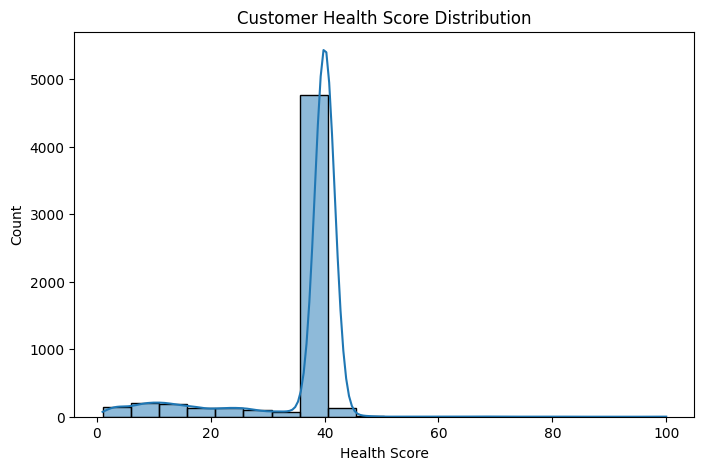

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_360["health_score"],
    bins=20,
    kde=True
)

plt.title("Customer Health Score Distribution")

plt.xlabel("Health Score")

plt.show()